# Deep Learning with PyTorch (Framework API)

In this notebook we implement a Multi-Layer Perceptron (MLP) for binary classification, but this time using PyTorch high-level tools (`nn.Module`, `nn.Sequential`, `DataLoader`, and optimizers).

This notebook is designed as the next step after `mlp_from_scratch_pytorch_solutions.ipynb`: same problem style, cleaner implementation.

## Learning goals
By the end of this notebook, you should be able to:
- Build an MLP with `nn.Sequential`.
- Train it with a standard PyTorch training loop.
- Use `BCEWithLogitsLoss` for binary classification.
- Compare optimizers and learning rates.
- Visualize loss curves and decision boundaries.


In [1]:
import torch as t
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(0)
t.manual_seed(0)


## 1. Dataset

We now use a harder binary dataset: **two noisy spirals** with a small amount of label noise.

Compared with concentric circles, this task has a more complex decision boundary and usually shows clearer differences between optimizer and learning-rate choices.


Train shape: torch.Size([480, 2]) torch.Size([480, 1])
Test shape:  torch.Size([120, 2]) torch.Size([120, 1])
Class balance in train: [238 242]
Class balance in test:  [60 60]


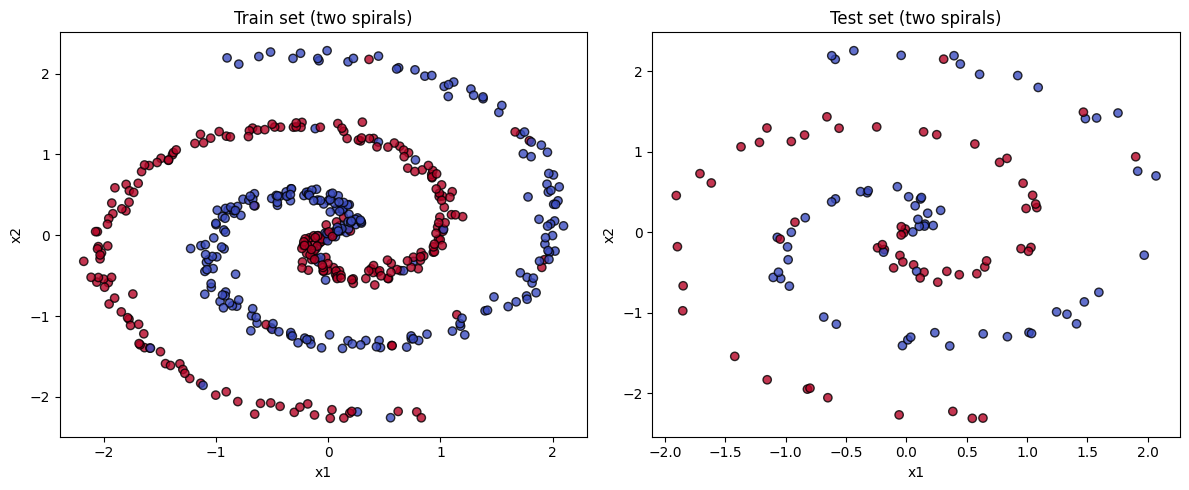

In [2]:
def make_two_spirals(n_samples=600, noise=0.20, rotations=2.6, label_noise=0.06, random_state=0):
    """Generate a challenging 2D binary dataset with two interleaving spirals."""
    if n_samples % 2 != 0:
        raise ValueError("n_samples must be even for a perfectly balanced split.")

    rng = np.random.default_rng(random_state)
    n_per_class = n_samples // 2

    theta = np.linspace(0.0, rotations * np.pi, n_per_class)
    radius = theta

    # Spiral for class 0
    x0 = np.column_stack((radius * np.cos(theta), radius * np.sin(theta)))

    # Opposite spiral for class 1
    x1 = np.column_stack((-radius * np.cos(theta), -radius * np.sin(theta)))

    X = np.vstack((x0, x1))
    y = np.hstack((np.zeros(n_per_class, dtype=np.int64), np.ones(n_per_class, dtype=np.int64)))

    # Add feature noise
    X += rng.normal(loc=0.0, scale=noise, size=X.shape)

    # Standardize features
    X = (X - X.mean(axis=0, keepdims=True)) / X.std(axis=0, keepdims=True)

    # Add a small amount of label noise to avoid near-perfect separability
    n_flip = int(label_noise * n_samples)
    if n_flip > 0:
        flip_idx = rng.choice(n_samples, size=n_flip, replace=False)
        y[flip_idx] = 1 - y[flip_idx]

    return X, y


X_np, y_np = make_two_spirals(
    n_samples=600,
    noise=0.20,
    rotations=2.6,
    label_noise=0.06,
    random_state=0,
)

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np,
    y_np,
    test_size=0.2,
    random_state=0,
    stratify=y_np,
)

X_train = t.tensor(X_train_np, dtype=t.float32)
X_test = t.tensor(X_test_np, dtype=t.float32)
y_train = t.tensor(y_train_np, dtype=t.float32).unsqueeze(1)
y_test = t.tensor(y_test_np, dtype=t.float32).unsqueeze(1)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape, y_test.shape)
print("Class balance in train:", np.bincount(y_train_np))
print("Class balance in test: ", np.bincount(y_test_np))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X_train_np[:, 0], X_train_np[:, 1], c=y_train_np, cmap="coolwarm", edgecolor="k", alpha=0.8)
ax[0].set_title("Train set (two spirals)")
ax[0].set_xlabel("x1")
ax[0].set_ylabel("x2")

ax[1].scatter(X_test_np[:, 0], X_test_np[:, 1], c=y_test_np, cmap="coolwarm", edgecolor="k", alpha=0.8)
ax[1].set_title("Test set (two spirals)")
ax[1].set_xlabel("x1")
ax[1].set_ylabel("x2")

plt.tight_layout()
plt.show()


## 2. TensorDataset and DataLoader

`TensorDataset` wraps tensors into a dataset object.

In [3]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

print("Number of train samples:", len(train_dataset))
print("Number of test samples: ", len(test_dataset))

Number of train samples: 480
Number of test samples:  120



`DataLoader` handles mini-batch creation and shuffling for us.

In [4]:
batch_size = 4

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of train batches:", len(train_loader))
print("Number of test batches: ", len(test_loader))

Number of train batches: 120
Number of test batches:  30


DataLoader also allows us to easily iterate over the dataset in batches during training and evaluation.

In [5]:
for train_features, train_labels in train_loader:
    print(f"Feature batch shape: {train_features.size()}")
    print(f"Labels batch shape: {train_labels.size()}")
    input_feats = train_features.squeeze()
    label = train_labels
    print(f"Feature values: {input_feats}")
    print(f"Label: {label}")

    # Stop after the first batch for demonstration purposes
    break

Feature batch shape: torch.Size([4, 2])
Labels batch shape: torch.Size([4, 1])
Feature values: tensor([[ 1.8166, -0.5913],
        [-0.8704,  0.3487],
        [-0.7126,  1.2216],
        [ 2.0095,  0.3834]])
Label: tensor([[0.],
        [0.],
        [1.],
        [0.]])


## 3. MLP model with `nn.Sequential`

In the from-scratch notebook, we manually stored `W1`, `b1`, `W2`, and `b2`.
Now PyTorch modules manage these parameters internally.

Each layer nn.Linear implements a linear transformation: $y = xW^T + b$. The first layer transforms from 2 input features to 10 hidden units, and the second layer transforms from 10 hidden units to 1 output unit.

Then after each linear layer, we apply a non-linear activation function (ReLU in this case) to introduce non-linearity into the model.


In [6]:
def build_mlp(input_size=2, hidden_size=16, output_size=1):
    """Create a one-hidden-layer MLP that outputs logits."""
    model = nn.Sequential(
        nn.Linear(input_size, hidden_size),
        nn.ReLU(),
        nn.Linear(hidden_size, output_size),
    )
    return model

def build_deep_mlp(input_size=2, hidden_sizes=[16, 16], output_size=1):
    """Create a deeper MLP with multiple hidden layers."""
    layers = []
    in_size = input_size
    for hidden_size in hidden_sizes:
        layers.append(nn.Linear(in_size, hidden_size))
        layers.append(nn.ReLU())
        in_size = hidden_size
    layers.append(nn.Linear(in_size, output_size))
    model = nn.Sequential(*layers)
    return model


model = build_mlp(hidden_size=16)
deep_model = build_deep_mlp(hidden_sizes=[16, 16])

print(model)
print(deep_model)

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)
Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)


By default, PyTorch initializes the weights of `nn.Linear` layers with Kaiming initialization:
$$
W \sim \mathcal{U}\left(-\sqrt{\frac{1}{\text{input\_size}}}, \sqrt{\frac{1}{\text{input\_size}}}\right)
$$

But we can also apply Xavier initialization manually if we want.

In [7]:
def initialize_weights_xavier(module):
    """Apply Xavier initialization to linear layers."""
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)

model.apply(initialize_weights_xavier)
model

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)

#### Loss function

We output **logits** (raw scores). This allow us to use `BCEWithLogitsLoss`, which is numerically more stable than applying `sigmoid` and `BCELoss` separately.

In [8]:
# Set the model to evaluation mode - important for batch normalization and dropout layers
# Unnecessary in this situation but added for best practices
model.eval()

with t.no_grad():
    sample_logits = model(X_train[:5])
    sample_probs = t.sigmoid(sample_logits)

    # First we create the loss function object, 
    loss_fn = nn.BCEWithLogitsLoss()
    # then we compute the loss for our sample logits and true labels.
    sample_loss = loss_fn(sample_logits, y_train[:5])

print("Logits shape:", sample_logits.shape)
print("Probabilities shape:", sample_probs.shape)
print("Sample probabilities:\\n", sample_probs.squeeze())
print("Sample loss:", sample_loss.item())


Logits shape: torch.Size([5, 1])
Probabilities shape: torch.Size([5, 1])
Sample probabilities:\n tensor([0.5522, 0.4383, 0.5690, 0.4108, 0.7404])
Sample loss: 0.6405341029167175


## 4. Loss and one optimization step

This cell shows one complete training step: forward pass, loss computation, backpropagation, and parameter update.

#### Optimizer
Here we introduce the optimizer object, which handles the parameter updates for us. We can choose different optimizers (SGD, Adam, etc.) and learning rates. Lets start with SGD and a learning rate of 0.1.


In [9]:
criterion = nn.BCEWithLogitsLoss()
optimizer = t.optim.SGD(model.parameters(), lr=0.1)

X_batch, y_batch = next(iter(train_loader))

optimizer.zero_grad()
logits = model(X_batch)
loss = criterion(logits, y_batch)
loss.backward()
optimizer.step()

print(f"Batch loss after one update: {loss.item():.4f}")


Batch loss after one update: 0.6545


## 5. Training and evaluation helpers

We now package the previous logic into reusable functions.


In [10]:
def predict_proba(model, X):
    """Return class-1 probabilities from logits."""
    model.eval()
    with t.no_grad():
        logits = model(X)
        probs = t.sigmoid(logits)
    return probs


def compute_accuracy(model, X, y, threshold=0.5):
    """Compute binary accuracy from probabilities."""
    probs = predict_proba(model, X)
    preds = (probs >= threshold).float()
    return (preds == y).float().mean().item()


def train_model(model, train_loader, criterion, optimizer, epochs=800, verbose_every=200):
    """Train for several epochs and return epoch-wise average loss."""
    losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        n_samples = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            batch_size_local = X_batch.size(0)
            running_loss += loss.item() * batch_size_local
            n_samples += batch_size_local

        epoch_loss = running_loss / n_samples
        losses.append(epoch_loss)

        if (epoch + 1) % verbose_every == 0:
            print(f"Epoch {epoch + 1}/{epochs} - Loss: {epoch_loss:.4f}")

    return losses


## 6. Baseline training (SGD)
Lets train a baseline model with SGD and a learning rate of 0.1 for 100 epochs.
A baseline model is a simple model that we can use as a reference point to compare against more complex models or different hyperparameters.

Use the previously implemented functions.
First create the model with the `build_model` function, then create the optimizer and loss function, and finally call the `train` function to train the model and `evaluate` function to check its performance on the training set.

In [11]:
t.manual_seed(0)

baseline_model = build_mlp(hidden_size=3)
baseline_model.apply(initialize_weights_xavier)

criterion = nn.BCEWithLogitsLoss()
baseline_optimizer = t.optim.SGD(baseline_model.parameters(), lr=0.1)

baseline_losses = train_model(
    baseline_model,
    train_loader,
    criterion,
    baseline_optimizer,
    epochs=800,
    verbose_every=200,
)

baseline_train_acc = compute_accuracy(baseline_model, X_train, y_train)
baseline_test_acc = compute_accuracy(baseline_model, X_test, y_test)

print(f"Train accuracy: {baseline_train_acc * 100:.2f}%")
print(f"Test accuracy:  {baseline_test_acc * 100:.2f}%")


Epoch 200/800 - Loss: 0.5904
Epoch 400/800 - Loss: 0.5885
Epoch 600/800 - Loss: 0.5892
Epoch 800/800 - Loss: 0.5897
Train accuracy: 65.42%
Test accuracy:  65.00%


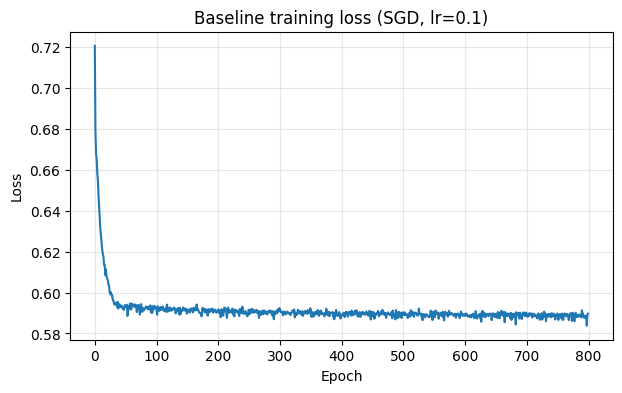

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(baseline_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline training loss (SGD, lr=0.1)")
plt.grid(alpha=0.3)
plt.show()


## 7. Decision boundary visualization

Same idea as in the previous notebook: create a grid in the input space and color it by model probability.


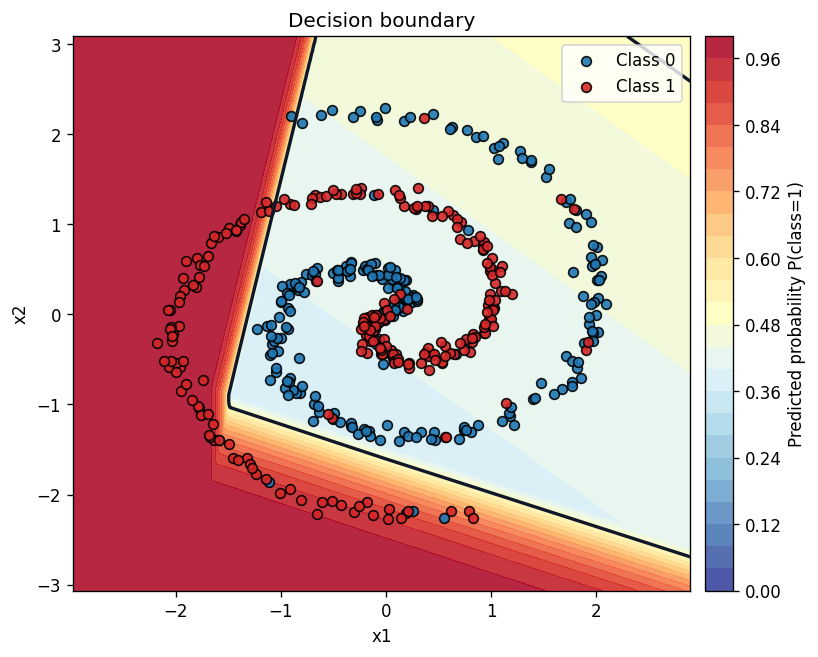

In [13]:
def plot_decision_boundary(model, X, y, grid_resolution=280, ax=None):
    """Plot decision surface, p=0.5 boundary, and data points."""
    X_np = X.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy().reshape(-1)

    x_min, x_max = X_np[:, 0].min() - 0.8, X_np[:, 0].max() + 0.8
    y_min, y_max = X_np[:, 1].min() - 0.8, X_np[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_resolution),
        np.linspace(y_min, y_max, grid_resolution),
    )

    grid_np = np.c_[xx.ravel(), yy.ravel()]
    grid = t.tensor(grid_np, dtype=X.dtype)

    with t.no_grad():
        probs = t.sigmoid(model(grid)).reshape(xx.shape).cpu().numpy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6), dpi=120)
    else:
        fig = ax.figure

    heat = ax.contourf(xx, yy, probs, levels=np.linspace(0, 1, 26), cmap="RdYlBu_r", alpha=0.88)
    ax.contour(xx, yy, probs, levels=[0.5], colors="#0f172a", linewidths=2.0)
    ax.scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1], c="#1f77b4", edgecolors="k", s=34, alpha=0.9, label="Class 0")
    ax.scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1], c="#d62728", edgecolors="k", s=34, alpha=0.9, label="Class 1")

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title("Decision boundary")
    ax.legend(loc="upper right")
    cbar = fig.colorbar(heat, ax=ax, pad=0.02)
    cbar.set_label("Predicted probability P(class=1)")

    return ax


plot_decision_boundary(baseline_model, X_train, y_train)
plt.show()


## 8. Compare optimizers and learning rates

Now we compare four setups:
- SGD with `lr=0.1`
- SGD with `lr=0.01`
- Adam with `lr=0.01`
- Adam with `lr=0.001`

We reset the model for every experiment (same random seed) so the comparison is fair.


In [14]:
def run_experiment(optimizer_name, lr, epochs=600, hidden_size=16):
    t.manual_seed(0)

    model = build_mlp(hidden_size=hidden_size)
    model.apply(initialize_weights_xavier)

    criterion = nn.BCEWithLogitsLoss()
    if optimizer_name == "SGD":
        optimizer = t.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "Adam":
        optimizer = t.optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("optimizer_name must be 'SGD' or 'Adam'.")

    losses = train_model(
        model,
        train_loader,
        criterion,
        optimizer,
        epochs=epochs,
        verbose_every=epochs + 1,
    )

    train_acc = compute_accuracy(model, X_train, y_train)
    test_acc = compute_accuracy(model, X_test, y_test)

    return {
        "model": model,
        "losses": losses,
        "train_acc": train_acc,
        "test_acc": test_acc,
    }


configs = [
    ("SGD", 0.1),
    ("SGD", 0.01),
    ("Adam", 0.01),
    ("Adam", 0.001),
]

results = {}
for optimizer_name, lr in configs:
    label = f"{optimizer_name} (lr={lr})"
    results[label] = run_experiment(optimizer_name, lr, epochs=600, hidden_size=16)
    print(
        f"{label:<18} | "
        f"Train acc: {results[label]['train_acc'] * 100:6.2f}% | "
        f"Test acc: {results[label]['test_acc'] * 100:6.2f}%"
    )


SGD (lr=0.1)       | Train acc:  92.08% | Test acc:  90.83%
SGD (lr=0.01)      | Train acc:  92.29% | Test acc:  91.67%
Adam (lr=0.01)     | Train acc:  92.08% | Test acc:  91.67%
Adam (lr=0.001)    | Train acc:  91.46% | Test acc:  90.83%


### Exercise: Try more optimizers and learning rates. 

Use the following optimizers from `torch.optim`:
- `torch.optim.SGD`
- `torch.optim.Adam`
- `torch.optim.RMSprop`

Look at the documentation for each optimizer to understand their parameters and how they work:

- [SGD documentation](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html)
- [Adam documentation](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html)
- [RMSprop documentation](https://pytorch.org/docs/stable/generated/torch.optim.RMSprop.html)

#### Questions:

- What is the name of the parameter that controls momentum in SGD? And the learning rate?
- What are the default values of $\beta_1$ and $\beta_2$ in Adam?
- What does $\alpha$ represent in RMSprop?

## Important note on hyperparameters:
> We will use the naming convention $\beta_1$ and $\beta_2$ for the hyperparameters controlling the moving average of the momentunm and the moving average of the squared gradients respectively in general. Despite the naming that Pytorch uses for other optimizers, we will stick to this convention for consistency across optimizers.

Play around with these hyperparameters and see how they affect the training process and the decision boundary.

- What happens if you set a very high learning rate (e.g., `lr=1.0`)?
- What happens if you set a very low $\beta_1$ in Adam (e.g., `beta_1=0.5`)?

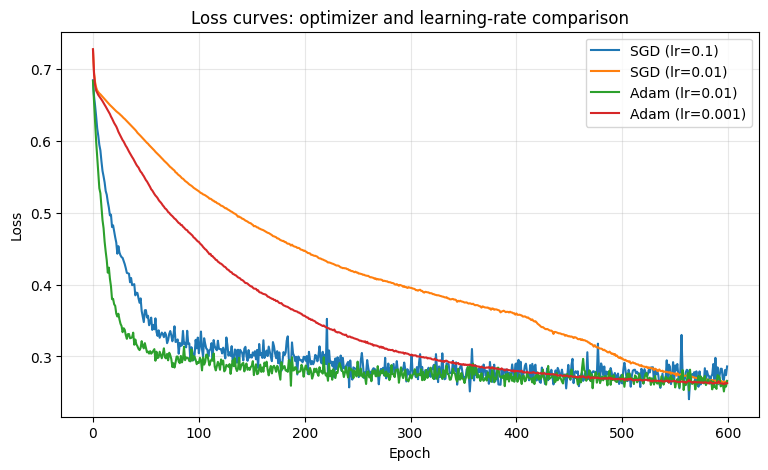

In [15]:
plt.figure(figsize=(9, 5))
for label, output in results.items():
    plt.plot(output["losses"], label=label)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves: optimizer and learning-rate comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


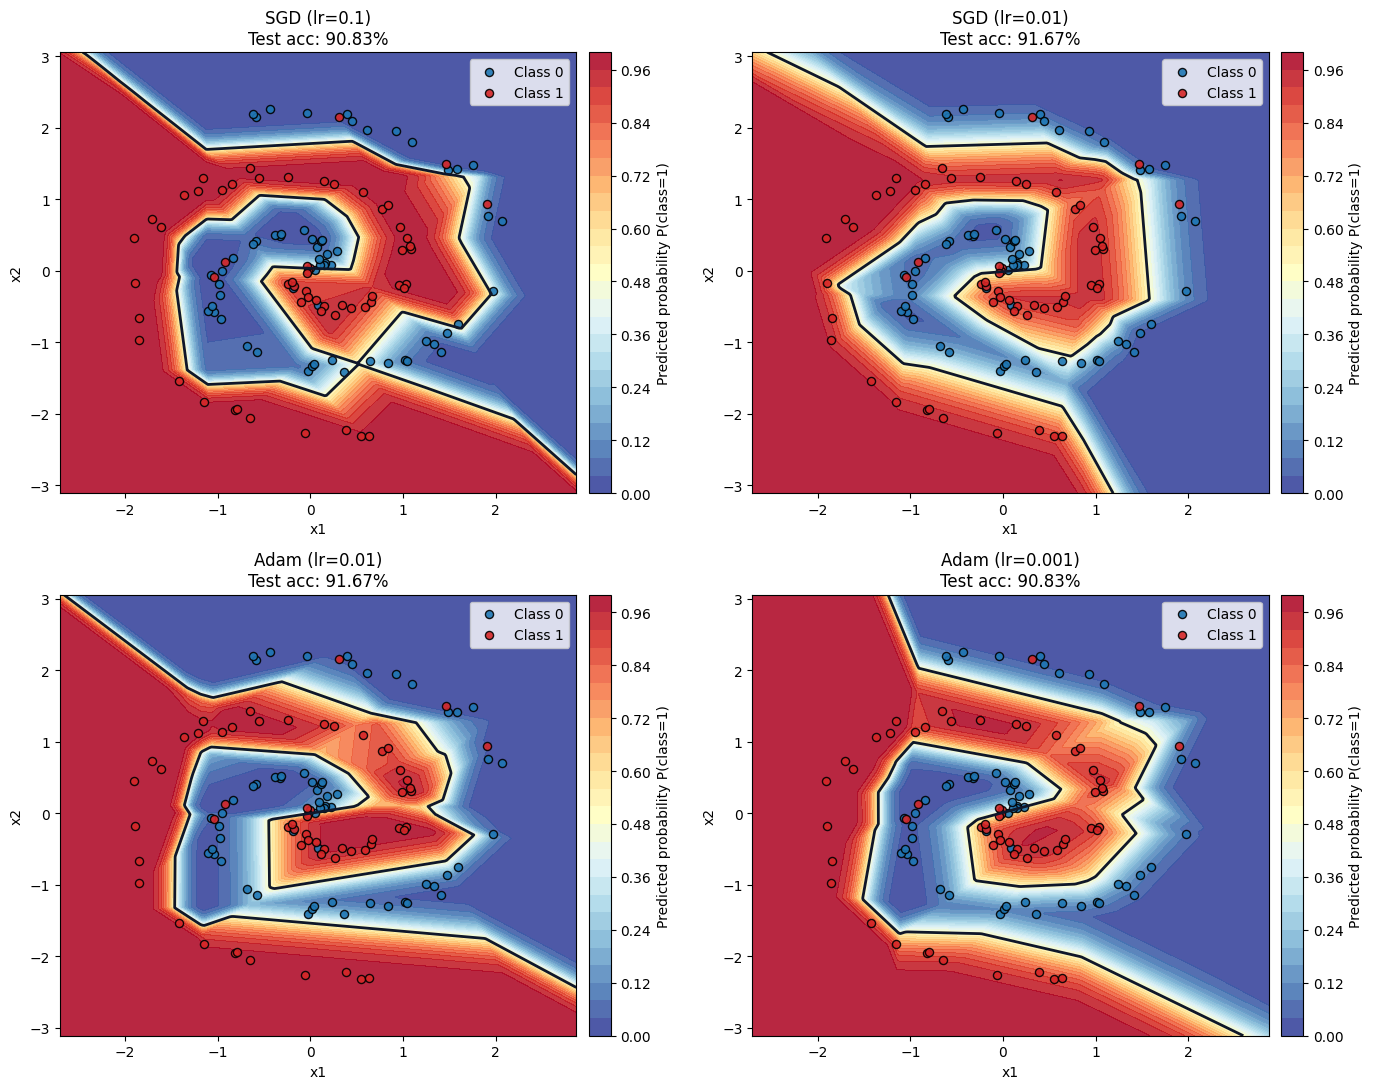

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, (label, output) in zip(axes.ravel(), results.items()):
    plot_decision_boundary(output["model"], X_test, y_test, ax=ax)
    ax.set_title(f"{label}\nTest acc: {output['test_acc'] * 100:.2f}%")

plt.tight_layout()
plt.show()


## 9. Takeaways

- `nn.Sequential` lets us define the network compactly and safely.
- `DataLoader` makes mini-batch training straightforward.
- The training loop structure is always: forward, loss, backward, optimizer step.
- Optimizer choice and learning rate strongly affect convergence speed and final performance.

This is the standard template you will reuse for deeper architectures (CNNs, RNNs/LSTMs, etc.).
